In [19]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
warnings.filterwarnings("ignore")
begDate    = "20231001"
endData    = "20240504"
sampleDate = "20240409"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = path.split('.')[0].split('/')[-1]

In [20]:
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
sample_1min_df.sort_index().head(200)

gid     rec_epoch     src_epoch  event  Trendslop_add_B  \
sid timeHMSf                                                                   
1.0 09:15:00.000000  1.0  1.743470e+09  1.743470e+09    1.0         0.000000   
    09:16:00.000000  1.0  1.743470e+09  1.743470e+09    1.0        -0.513453   
    09:17:00.000000  1.0  1.743470e+09  1.743470e+09    1.0         0.118230   
    09:18:00.000000  1.0  1.743470e+09  1.743470e+09    1.0         0.295588   
    09:19:00.000000  1.0  1.743470e+09  1.743470e+09    1.0        -0.141113   
    09:20:00.000000  1.0  1.743470e+09  1.743470e+09    1.0        -0.151558   
    09:21:00.000000  1.0  1.743470e+09  1.743470e+09    1.0         0.129730   
    09:22:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.065111   
    09:23:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.015505   
    09:24:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.061596   
    09:25:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.237420   
    09:26:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.000000   
    09:27:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.000000   
    09:28:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.000000   
    09:29:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.000000   
    09:30:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.000000   
    09:31:00.000000  1.0  1.743471e+09  1.743471e+09    1.0        -0.009118   
    09:32:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.052157   
    09:33:00.000000  1.0  1.743471e+09  1.743471e+09    1.0        -0.019241   
    09:34:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.004154   
    09:35:00.000000  1.0  1.743471e+09  1.743471e+09    1.0        -0.005728   
    09:36:00.000000  1.0  1.743471e+09  1.743471e+09    1.0        -0.102079   
    09:37:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.077086   
    09:38:00.000000  1.0  1.743471e+09  1.743471e+09    1.0         0.072509   
    09:39:00.000000  1.0  1.743472e+09  1.743472e+09    1.0        -0.096676   
    09:40:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.044248   
    09:41:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.005462   
    09:42:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.180390   
    09:43:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.007909   
    09:44:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.035635   
    09:45:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.057679   
    09:46:00.000000  1.0  1.743472e+09  1.743472e+09    1.0        -0.026555   
    09:47:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.108599   
    09:48:00.000000  1.0  1.743472e+09  1.743472e+09    1.0        -0.009989   
    09:49:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.016930   
    09:50:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.069900   
    09:51:00.000000  1.0  1.743472e+09  1.743472e+09    1.0        -0.062703   
    09:52:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.067464   
    09:53:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.009518   
    09:54:00.000000  1.0  1.743472e+09  1.743472e+09    1.0         0.009252   
    09:55:00.000000  1.0  1.743472e+09  1.743472e+09    1.0        -0.031735   
    09:56:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.002279   
    09:57:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.148470   
    09:58:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.048165   
    09:59:00.000000  1.0  1.743473e+09  1.743473e+09    1.0        -0.048069   
    10:00:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.091485   
    10:01:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.031766   
    10:02:00.000000  1.0  1.743473e+09  1.743473e+09    1.0         0.092185   
    10:03:00.000000  

In [3]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 138/138 [00:01<00:00, 100.43it/s]
[Parallel(n_jobs=100)]: Done   9 out of 138 | elapsed:    5.1s remaining:  1.2min
[Parallel(n_jobs=100)]: Done  23 out of 138 | elapsed:    5.4s remaining:   26.8s
[Parallel(n_jobs=100)]: Done  37 out of 138 | elapsed:    5.6s remaining:   15.2s
[Parallel(n_jobs=100)]: Done  51 out of 138 | elapsed:    5.8s remaining:    9.9s
[Parallel(n_jobs=100)]: Done  65 out of 138 | elapsed:    6.0s remaining:    6.7s
[Parallel(n_jobs=100)]: Done  79 out of 138 | elapsed:    6.2s remaining:    4.6s
[Parallel(n_jobs=100)]: Done  93 out of 138 | elapsed:    6.4s remaining:    3.1s
[Parallel(n_jobs=100)]: Done 107 out of 138 | elapsed:    6.7s remaining:    2.0s
[Parallel(n_jobs=100)]: Done 121 out of 138 | elapsed:    7.0s remaining:    1.0s
[Parallel(n_jobs=100)]: Done 135 out of 138 | elapsed:    7.2s remaining:    0.2s
[Parallel(n_jobs=100)]: Done 138 out of 138 | elapsed:    7.2s finished


In [4]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [4]:

# sampleDate = "20240409"
root_dir = '/data/nfs0/chinaEquityData/panel/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}5min/5min-{sampleDate}.sdiv").sel(V = slice("midPriceLastValid", "close.avg"))
    )
    return sample_1min_df


Process_1min_df_2 = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df_2 = pd.concat(Process_1min_df_2, ignore_index=True)
feature_1min_df_2 = feature_1min_df_2.set_index(['sid','date','time'])

100%|██████████| 138/138 [00:00<00:00, 39781.03it/s]
[Parallel(n_jobs=100)]: Done   9 out of 138 | elapsed:    2.6s remaining:   37.0s
[Parallel(n_jobs=100)]: Done  23 out of 138 | elapsed:    4.4s remaining:   22.2s
[Parallel(n_jobs=100)]: Done  37 out of 138 | elapsed:    6.5s remaining:   17.7s
[Parallel(n_jobs=100)]: Done  51 out of 138 | elapsed:    8.4s remaining:   14.3s
[Parallel(n_jobs=100)]: Done  65 out of 138 | elapsed:   10.3s remaining:   11.5s
[Parallel(n_jobs=100)]: Done  79 out of 138 | elapsed:   12.3s remaining:    9.2s
[Parallel(n_jobs=100)]: Done  93 out of 138 | elapsed:   14.3s remaining:    6.9s
[Parallel(n_jobs=100)]: Done 107 out of 138 | elapsed:   16.2s remaining:    4.7s
[Parallel(n_jobs=100)]: Done 121 out of 138 | elapsed:   18.0s remaining:    2.5s
[Parallel(n_jobs=100)]: Done 135 out of 138 | elapsed:   19.9s remaining:    0.4s
[Parallel(n_jobs=100)]: Done 138 out of 138 | elapsed:   20.3s finished


In [5]:
feature_1min_df

index  Trendslop_add_B  Trendslop_add_S  \
sid  date     time                                                  
10   20231102 09:35:00  1164096         0.000011        -0.000497   
              09:40:00  1164097        -0.000019        -0.000062   
              09:45:00  1164098         0.000043         0.000057   
              09:50:00  1164099        -0.000010        -0.000277   
              09:55:00  1164100        -0.000014         0.000158   
...                         ...              ...              ...   
9995 20240430 14:40:00  8520571        -0.000028        -0.000115   
              14:45:00  8520572        -0.000140        -0.000078   
              14:50:00  8520573         0.000074         0.000006   
              14:55:00  8520574        -0.000113        -0.000117   
              15:00:00  8520575         0.000048        -0.000159   

                        autoCorrHalf_add_B_Prc  autoCorrHalf_add_S_Prc  \
sid  date     time                                                       
10   20231102 09:35:00                0.000000               -0.063404   
              09:40:00                0.000000               -0.086031   
              09:45:00               -0.007166               -0.071452   
              09:50:00                0.000000                0.000000   
              09:55:00                0.000000                0.000946   
...                                        ...                     ...   
9995 20240430 14:40:00               -0.052630                0.003159   
              14:45:00                0.116063                0.000000   
              14:50:00               -0.049517                0.173703   
              14:55:00                0.000000                0.000000   
              15:00:00                0.000000               -0.143003   

                        autoCorrHalf_add_B_Qty  autoCorrHalf_add_S_Qty  
sid  date     time                                                      
10   20231102 09:35:00                0.000000               -0.018712  
              09:40:00                0.000000               -0.027239  
              09:45:00               -0.027879               -0.014942  
              09:50:00                0.000000                0.000000  
              09:55:00                0.000000                0.026656  
...                                        ...                     ...  
9995 20240430 14:40:00                0.017388                0.032796  
              14:45:00               -0.045087                0.000000  
              14:50:00               -0.045386               -0.227538  
              14:55:00                0.000000                0.000000  
              15:00:00                0.000000                0.070352  

[8545200 rows x 7 columns]

In [6]:
label_df = pd.read_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet")

feature_1min_df['Trendslop_add_BS'] = (feature_1min_df['Trendslop_add_B'] - feature_1min_df['Trendslop_add_S']) 
feature_1min_df['Trendslop_add_addBS'] = (feature_1min_df['Trendslop_add_B'] + feature_1min_df['Trendslop_add_S']) 

In [7]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

In [13]:
feature_all_df.columns

Index(['index', 'Trendslop_add_B', 'Trendslop_add_S', 'autoCorrHalf_add_B_Prc',
       'autoCorrHalf_add_S_Prc', 'autoCorrHalf_add_B_Qty',
       'autoCorrHalf_add_S_Qty', 'Trendslop_add_BS', 'Trendslop_add_addBS',
       'ret1h', 'ret0e', 'is.active', 'ret0e_shift', 'ret1h_shift'],
      dtype='object')

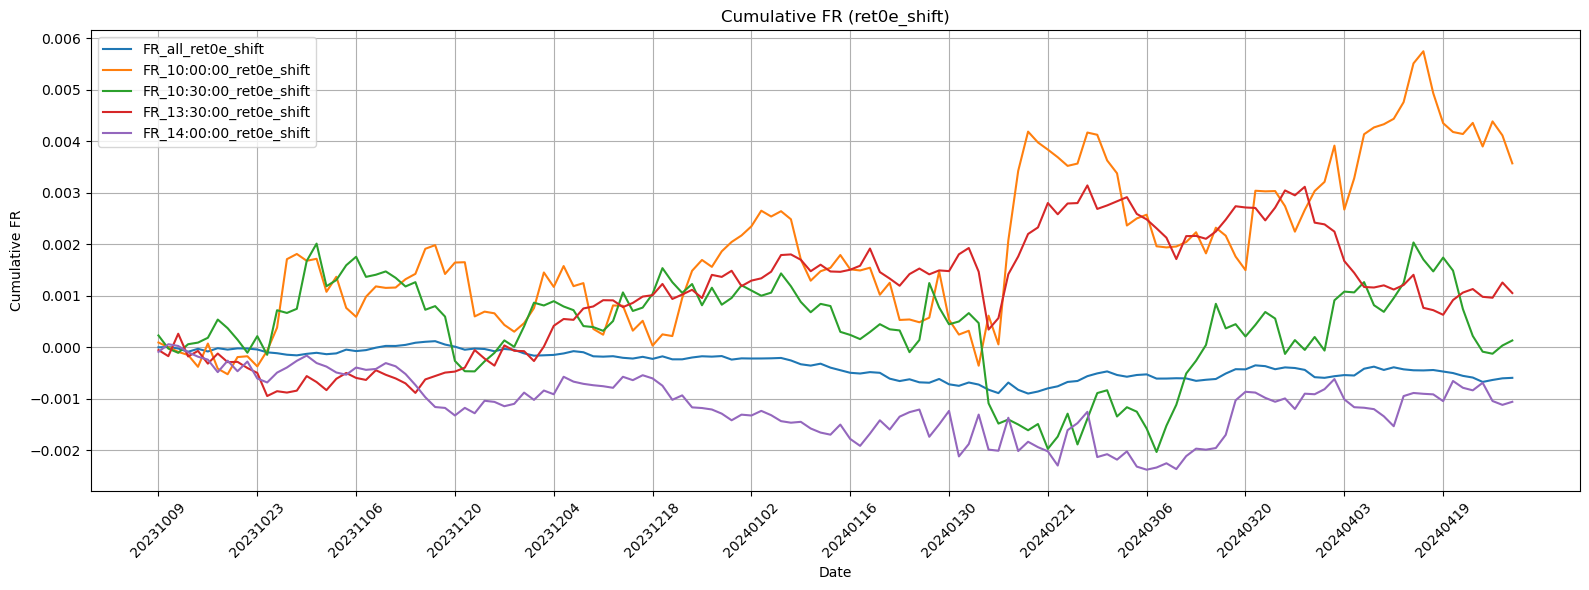

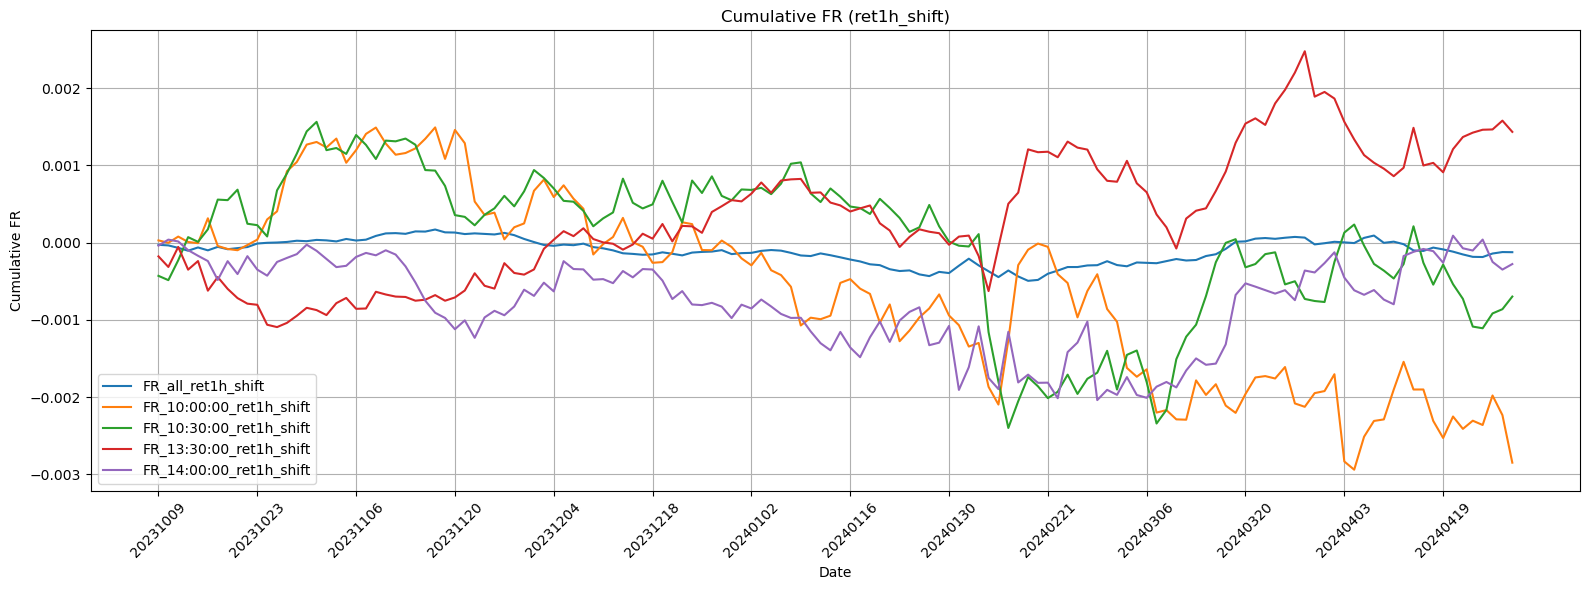

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你已经有以下变量
feat_col = 'autoCorrHalf_add_B_Qty'
ret_cols = ['ret0e_shift', 'ret1h_shift']
time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

df = feature_all_df.reset_index()

# ---------- 全部时间点 (FR_all_*) ----------
fr_all_results = {}
for ret_col in ret_cols:
    sub_df = df[[feat_col, ret_col, 'date']].dropna()

    # 按date groupby，计算 FR = cov(x, y) / std(x)
    grouped = sub_df.groupby('date')
    mean_x = grouped[feat_col].transform('mean')
    mean_y = grouped[ret_col].transform('mean')
    std_x = grouped[feat_col].transform('std')

    cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
    std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

    fr = cov_xy / std_x_daily.replace(0, np.nan)
    fr_all_results[f'FR_all_{ret_col}'] = fr

# ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
fr_time_results = {}

for tp in time_points:
    df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
    for ret_col in ret_cols:
        grouped = df_tp.groupby('date')
        x = df_tp[feat_col]
        y = df_tp[ret_col]
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
        std_x_daily = std_x.groupby(df_tp['date']).first()

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_time_results[f'FR_{tp}_{ret_col}'] = fr

# 合并所有结果
fr_all_df = pd.DataFrame(fr_all_results)
fr_time_df = pd.DataFrame(fr_time_results)
fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

# 计算 cumulative FR
cumulative_fr_df = fr_df.cumsum()


# 分别提取 ret0e 和 ret1h 的 FR 列
fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

# 画 ret0e_shift 的 Cumulative FR 图
plt.figure(figsize=(16, 6))
for col in fr_0e_cols:
    plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

plt.title('Cumulative FR (ret0e_shift)')
plt.xlabel('Date')
plt.ylabel('Cumulative FR')
plt.legend()
plt.grid(True)
plt.xticks(cumulative_fr_df.index[::10], rotation=45)
plt.tight_layout()
plt.show()

# 画 ret1h_shift 的 Cumulative FR 图
plt.figure(figsize=(16, 6))
for col in fr_1h_cols:
    plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

plt.title('Cumulative FR (ret1h_shift)')
plt.xlabel('Date')
plt.ylabel('Cumulative FR')
plt.legend()
plt.grid(True)
plt.xticks(cumulative_fr_df.index[::10], rotation=45)
plt.tight_layout()
plt.show()
